# FitRank -> Training Set Size Ablation

Fine-tunes `cross-encoder/ms-marco-MiniLM-L-6-v2` on increasing subsets of the training pairs, using the exact same hyperparameters as the full-size run, and evaluates each against the same 168-pair hand-labeled eval set.



In [1]:
!pip install -q -U sentence-transformers datasets scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.8 MB/s eta 0:00:00


In [2]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
Device: Tesla T4


## 1. Load data


In [4]:
from google.colab import files
uploaded = files.upload()

Saving eval_pairs_blind.csv to eval_pairs_blind.csv
Saving labeled_eval_fixed.csv to labeled_eval_fixed.csv


In [5]:
import pandas as pd
import numpy as np

train_full = pd.read_csv("train_pairs.csv")
eval_blind = pd.read_csv("eval_pairs_blind.csv")
labeled = pd.read_csv("labeled_eval_fixed.csv")

eval_df = eval_blind.drop(columns=["human_label"]).merge(
    labeled[["resume_id", "job_id", "human_label"]], on=["resume_id", "job_id"]
)

print(f"Full train pool: {len(train_full)} pairs")
print(f"Eval set: {len(eval_df)} pairs")

def truncate_words(text, max_words=250):
    # matches the truncation policy used at inference time
    return " ".join(str(text).split()[:max_words])

def precision_at_1(df, score_col, label_col="human_label"):
    correct, total = 0, 0
    for rid, grp in df.groupby("resume_id"):
        if grp[label_col].sum() == 0:
            continue
        top = grp.loc[grp[score_col].idxmax()]
        correct += int(top[label_col] == 1)
        total += 1
    return correct / total, correct, total

Full train pool: 6729 pairs
Eval set: 168 pairs


## 2. Ablation loop

Same hyperparameters as the full size run (3 epochs, batch size 16, lr 2e-5, warmup 0.1). Each subset is a stratified sample by label, so the positive/negative ratio matches the full training pool at every size.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from datasets import Dataset
from sentence_transformers.cross_encoder import (
    CrossEncoder,
    CrossEncoderTrainer,
    CrossEncoderTrainingArguments,
)
from sentence_transformers.cross_encoder.losses import BinaryCrossEntropyLoss
from sentence_transformers.cross_encoder.evaluation import CrossEncoderClassificationEvaluator

MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"
SUBSET_SIZES = [500, 1000, 2000, 4000]  # 6729 (full) already has a result: 0.871 AUC / 0.778 P@1

eval_pairs = list(zip(
    eval_df["resume_text"].apply(truncate_words).tolist(),
    eval_df["job_text"].tolist(),
))

results = []

for size in SUBSET_SIZES:
    print(f"\n{'='*50}\nTraining on {size} pairs\n{'='*50}")

    subset, _ = train_test_split(
        train_full, train_size=size, stratify=train_full["label"], random_state=42
    )
    subset = subset.reset_index(drop=True)
    subset["resume_text_trunc"] = subset["resume_text"].apply(truncate_words)

    subset = subset.sample(frac=1, random_state=42).reset_index(drop=True)
    n_val = max(1, int(len(subset) * 0.05))
    val_df = subset.iloc[:n_val]
    train_df = subset.iloc[n_val:]

    train_dataset = Dataset.from_dict({
        "query": train_df["resume_text_trunc"].tolist(),
        "response": train_df["job_text"].tolist(),
        "label": train_df["label"].astype(float).tolist(),
    })
    val_dataset = Dataset.from_dict({
        "query": val_df["resume_text_trunc"].tolist(),
        "response": val_df["job_text"].tolist(),
        "label": val_df["label"].astype(float).tolist(),
    })

    model = CrossEncoder(MODEL_NAME, num_labels=1, max_length=512)
    loss = BinaryCrossEntropyLoss(model)
    evaluator = CrossEncoderClassificationEvaluator(
        sentence_pairs=list(zip(val_dataset["query"], val_dataset["response"])),
        labels=val_dataset["label"],
        name="val-monitoring",
    )

    args = CrossEncoderTrainingArguments(
        output_dir=f"fitrank-ablation-{size}",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        fp16=torch.cuda.is_available(),
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        load_best_model_at_end=False,
        report_to=[],
    )

    trainer = CrossEncoderTrainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        loss=loss,
        evaluator=evaluator,
    )
    trainer.train()

    scores = model.predict(eval_pairs)
    eval_df[f"score_{size}"] = scores

    auc = roc_auc_score(eval_df["human_label"], scores)
    p1, correct, total = precision_at_1(eval_df, f"score_{size}")

    print(f"\n>>> size={size}  AUC-ROC={auc:.3f}  P@1={p1:.3f} ({correct}/{total})")
    results.append({"train_size": size, "auc_roc": auc, "precision_at_1": p1})

    del model, trainer
    torch.cuda.empty_cache()


Training on 500 pairs


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Val-monitoring Accuracy,Val-monitoring Accuracy Threshold,Val-monitoring F1,Val-monitoring F1 Threshold,Val-monitoring Precision,Val-monitoring Recall,Val-monitoring Average Precision
1,0.682891,0.560528,0.750000,0.076530,0.796748,0.076530,0.720588,0.890909,0.835972
2,0.474702,0.438255,0.820000,1.226074,0.842105,0.085083,0.813559,0.872727,0.911953
3,0.408600,0.429849,0.840000,-0.344604,0.859649,-0.344604,0.830508,0.890909,0.916636



>>> size=2000  AUC-ROC=0.853  P@1=0.833 (15/18)

Training on 4000 pairs


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Val-monitoring Accuracy,Val-monitoring Accuracy Threshold,Val-monitoring F1,Val-monitoring F1 Threshold,Val-monitoring Precision,Val-monitoring Recall,Val-monitoring Average Precision
1,0.525431,0.463933,0.810000,-0.642334,0.820755,-0.642334,0.805556,0.836538,0.906953
2,0.360900,0.382489,0.870000,-0.817139,0.876190,-0.976807,0.867925,0.884615,0.942491
3,0.314742,0.399382,0.875000,-0.698975,0.878049,-0.698975,0.891089,0.865385,0.949738



>>> size=4000  AUC-ROC=0.856  P@1=0.778 (14/18)


## 3. Results

In [7]:
# add the already known full size result
results.append({"train_size": 6729, "auc_roc": 0.871, "precision_at_1": 0.778})

results_df = pd.DataFrame(results).sort_values("train_size").reset_index(drop=True)
print(results_df)

results_df.to_csv("ablation_results.csv", index=False)
files.download("ablation_results.csv")

   train_size   auc_roc  precision_at_1
0         500  0.777801        0.722222
1        1000  0.813183        0.777778
2        2000  0.852796        0.833333
3        4000  0.855787        0.777778
4        6729  0.871000        0.778000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

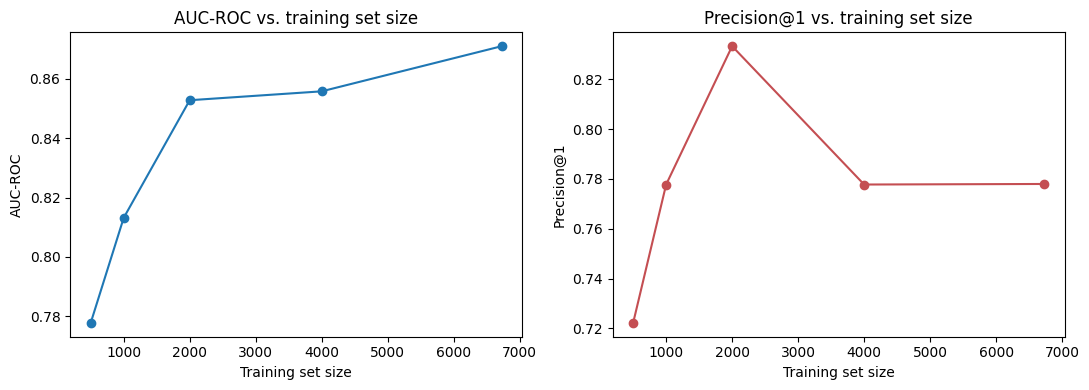

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(results_df["train_size"], results_df["auc_roc"], marker="o")
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("AUC-ROC")
axes[0].set_title("AUC-ROC vs. training set size")

axes[1].plot(results_df["train_size"], results_df["precision_at_1"], marker="o", color="#C44E52")
axes[1].set_xlabel("Training set size")
axes[1].set_ylabel("Precision@1")
axes[1].set_title("Precision@1 vs. training set size")

plt.tight_layout()
plt.show()